# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [1]:
# Load the libraries as required.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')

/usr/local/Caskroom/miniconda/base/envs/dsi_participant/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


# Get X and Y

Create the features data frame and target data.

In [3]:
# Get X and Y
X = fires_dt.drop('area', axis=1)
y = fires_dt['area']


In [4]:
# Identify numeric and categorical features
numeric_features = ['coord_x','coord_y','ffmc','dmc','dc','isi','temp','rh','wind','rain']
categorical_features = ['month','day']

# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [5]:
# Preproc 1: scaling + OHE
preproc1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])


### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [6]:
# Preproc 2: scaling + non-linear power transform on numeric
preproc2 = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('transform', PowerTransformer(method='yeo-johnson')),
            ('scale', StandardScaler())
        ]), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])

## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [7]:
# Pipeline A = preproc1 + baseline
pipe_A = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', Ridge(random_state=42))
])

In [8]:
# Pipeline B = preproc2 + baseline
pipe_B = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', Ridge(random_state=42))
])

In [9]:
# Pipeline C = preproc1 + advanced model
pipe_C = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])

In [10]:
# Pipeline D = preproc2 + advanced model
pipe_D = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])
    

# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [11]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# Tuning Hyperparameters

# For RMSE scoring (lower is better)
scoring = 'neg_mean_squared_error'

# Pipeline A - Ridge with preproc1
param_grid_a = {
    'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
}

grid_a = GridSearchCV(pipe_A, param_grid_a, cv=5, scoring=scoring, n_jobs=-1)
grid_a.fit(X_train, y_train)

# Pipeline B - Ridge with preproc2
param_grid_b = {
    'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
}

grid_b = GridSearchCV(pipe_B, param_grid_b, cv=5, scoring=scoring, n_jobs=-1)
grid_b.fit(X_train, y_train)

# Pipeline C - Random Forest with preproc1
param_grid_c = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [5, 10, None],
    'regressor__min_samples_split': [2, 5, 10]
}

grid_c = GridSearchCV(pipe_C, param_grid_c, cv=5, scoring=scoring, n_jobs=-1)
grid_c.fit(X_train, y_train)

# Pipeline D - Random Forest with preproc2
param_grid_d = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [5, 10, None],
    'regressor__min_samples_split': [2, 5, 10]
}


/usr/local/Caskroom/miniconda/base/envs/dsi_participant/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:982: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/Caskroom/miniconda/base/envs/dsi_participant/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 971, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/usr/local/Caskroom/miniconda/base/envs/dsi_participant/lib/python3.9/site-packages/sklearn/metrics/_scorer.py", line 279, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "/usr/local/Caskroom/miniconda/base/envs/dsi_participant/lib/python3.9/site-packages/sklearn/metrics/_scorer.py", line 371, in _score
    y_pred = method_caller(
  File "/usr/local/Caskroom/miniconda/base/envs/dsi_participant/lib/python3.9/site-packages/sklearn/metri

In [13]:
# run gridsearch
grid_d = GridSearchCV(pipe_D, param_grid_d, cv=5, scoring=scoring, n_jobs=-1)
grid_d.fit(X_train, y_train)

/usr/local/Caskroom/miniconda/base/envs/dsi_participant/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:982: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/Caskroom/miniconda/base/envs/dsi_participant/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 971, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/usr/local/Caskroom/miniconda/base/envs/dsi_participant/lib/python3.9/site-packages/sklearn/metrics/_scorer.py", line 279, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "/usr/local/Caskroom/miniconda/base/envs/dsi_participant/lib/python3.9/site-packages/sklearn/metrics/_scorer.py", line 371, in _score
    y_pred = method_caller(
  File "/usr/local/Caskroom/miniconda/base/envs/dsi_participant/lib/python3.9/site-packages/sklearn/metri

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('transform',
                                                                                          PowerTransformer()),
                                                                                         ('scale',
                                                                                          StandardScaler())]),
                                                                         ['coord_x',
                                                                          'coord_y',
                                                                          'ffmc',
                                                                          'dmc',
                                                                          'dc',
                                                                          'isi',
                                                                          'temp',
                                                                          'rh',
                                                                          'wind',
                                                                          'rain']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       sparse_output=False),
                                                                         ['month',
                                                                          'day'])])),
                                       ('regressor',
                                        RandomForestRegressor(n_jobs=-1,
                                                              random_state=42))]),
             n_jobs=-1,
             param_grid={'regressor__max_depth': [5, 10, None],
                         'regressor__min_samples_split': [2, 5, 10],
                         'regressor__n_estimators': [50, 100, 200]},
             scoring='neg_mean_squared_error')

# Evaluate

+ Which model has the best performance?

In [14]:
# Evaluate models
def evaluate_model(grid, X_test, y_test, name):
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n{name} Performance:")
    print(f"Best params: {grid.best_params_}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R squared: {r2:.4f}")
    
    return {'name': name, 'model': best_model, 'rmse': rmse, 'mae': mae, 'r2': r2}

# Evaluate all models
results = []
results.append(evaluate_model(grid_a, X_test, y_test, "Pipeline A (Preproc1 + Ridge)"))
results.append(evaluate_model(grid_b, X_test, y_test, "Pipeline B (Preproc2 + Ridge)"))
results.append(evaluate_model(grid_c, X_test, y_test, "Pipeline C (Preproc1 + Random Forest)"))
results.append(evaluate_model(grid_d, X_test, y_test, "Pipeline D (Preproc2 + Random Forest)"))

# Find best model
best_result = min(results, key=lambda x: x['rmse'])
print(f"\n BEST MODEL: {best_result['name']} ")
print(f"RMSE: {best_result['rmse']:.4f}")


Pipeline A (Preproc1 + Ridge) Performance:
Best params: {'regressor__alpha': 0.001}
RMSE: 107.7670
MAE: 24.5251
R squared: 0.0148

Pipeline B (Preproc2 + Ridge) Performance:
Best params: {'regressor__alpha': 0.001}
RMSE: 107.5568
MAE: 24.7208
R squared: 0.0186

Pipeline C (Preproc1 + Random Forest) Performance:
Best params: {'regressor__max_depth': 5, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 50}
RMSE: 109.3163
MAE: 25.6902
R squared: -0.0138

Pipeline D (Preproc2 + Random Forest) Performance:
Best params: {'regressor__max_depth': 5, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 50}
RMSE: 109.3390
MAE: 25.2569
R squared: -0.0142

 BEST MODEL: Pipeline B (Preproc2 + Ridge) 
RMSE: 107.5568


# Export

+ Save the best performing model to a pickle file.

In [15]:
# Export best model
best_model = best_result['model']

# Save to pickle file
with open('best_forest_fire_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Best model saved as 'best_forest_fire_model.pkl'")


Best model saved as 'best_forest_fire_model.pkl'


# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In [16]:
# Explain with SHAP

# Prepare data for SHAP
preprocessor = best_model.named_steps['preprocessing']
regressor = best_model.named_steps['regressor']

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names after preprocessing
numeric_features_processed = numeric_features
categorical_features_processed = list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))
all_feature_names = numeric_features_processed + categorical_features_processed

print(f"Regressor type: {type(regressor)}")

# Create appropriate SHAP explainer based on model type
if hasattr(regressor, 'coef_'):  # Linear models (Ridge)
    print("Using LinearExplainer for linear model")
    explainer = shap.LinearExplainer(regressor, X_train_processed)
    shap_values = explainer.shap_values(X_test_processed)
else:  # Tree-based models
    print("Using TreeExplainer for tree-based model")
    explainer = shap.TreeExplainer(regressor)
    shap_values = explainer.shap_values(X_test_processed)

print("SHAP explanation ready!")

Regressor type: <class 'sklearn.linear_model._ridge.Ridge'>
Using LinearExplainer for linear model
SHAP explanation ready!


<Figure size 1000x600 with 0 Axes>

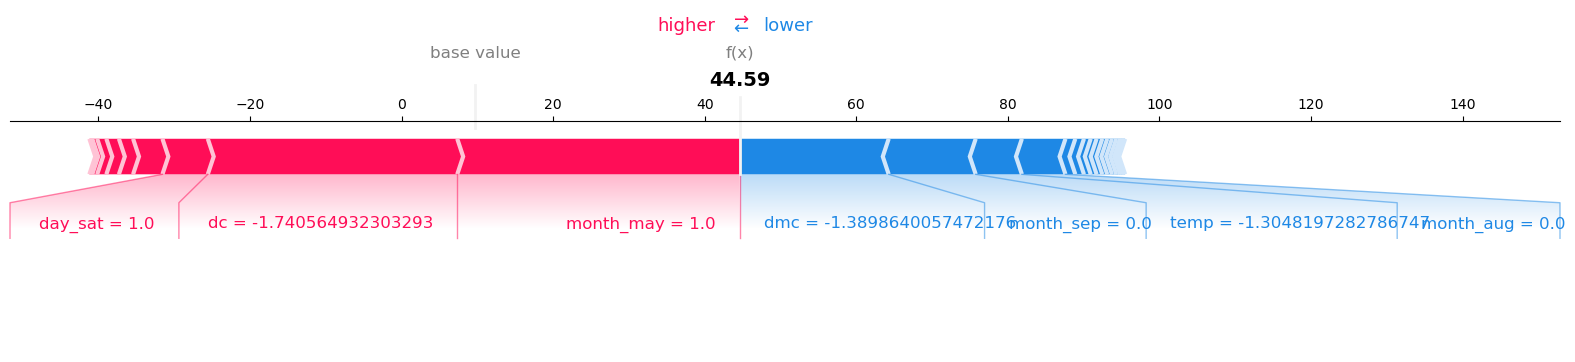

Actual area burned: 0.00 ha
Predicted area burned: 44.59 ha

Feature values for this observation:
coord_x: 6
coord_y: 5
month: may
day: sat
ffmc: 85.1
dmc: 28.0
dc: 113.8
isi: 3.5
temp: 11.3
rh: 94
wind: 4.9
rain: 0.0


In [17]:
# select first observation in test set
observation_idx = 0

plt.figure(figsize=(10, 6))
shap.force_plot(explainer.expected_value, 
                shap_values[observation_idx], 
                X_test_processed[observation_idx],
                feature_names=all_feature_names,
                matplotlib=True)

print(f"Actual area burned: {y_test.iloc[observation_idx]:.2f} ha")
print(f"Predicted area burned: {best_model.predict(X_test.iloc[[observation_idx]])[0]:.2f} ha")

# Show feature values for this observation
print("\nFeature values for this observation:")
for feature in X_test.columns:
    print(f"{feature}: {X_test.iloc[observation_idx][feature]}")


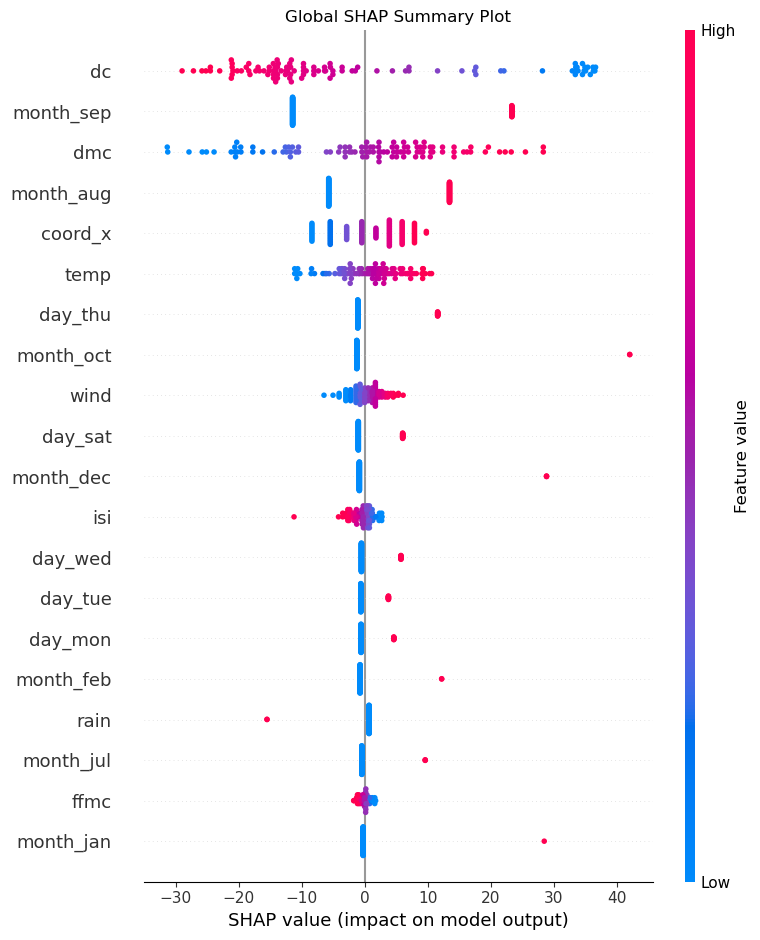

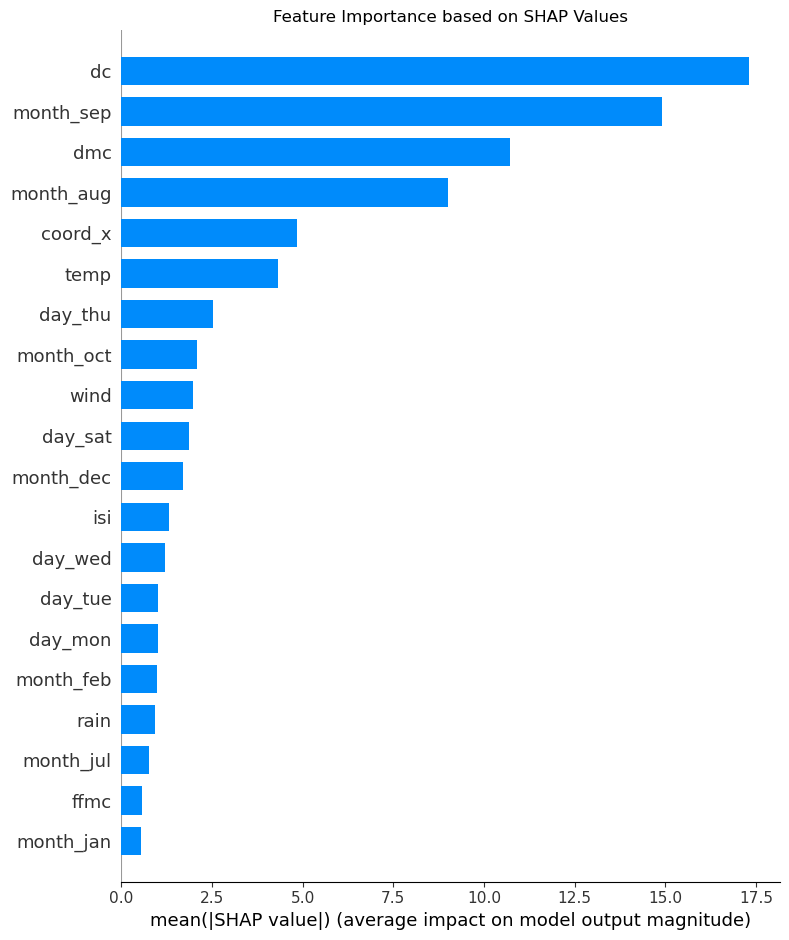

In [18]:
# Global explanation - Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_processed, feature_names=all_feature_names, show=False)
plt.title("Global SHAP Summary Plot")
plt.tight_layout()
plt.show()

# Feature importance bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_processed, feature_names=all_feature_names, plot_type="bar", show=False)
plt.title("Feature Importance based on SHAP Values")
plt.tight_layout()
plt.show()

In [19]:
# Get detailed feature importance
mean_abs_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'feature': all_feature_names,
    'importance': mean_abs_shap
}).sort_values('importance', ascending=False)

print("\nFeature Importance (based on mean |SHAP| values):")
print(feature_importance.to_string(index=False))

# Calculate percentage contribution
total_importance = feature_importance['importance'].sum()
feature_importance['percentage'] = (feature_importance['importance'] / total_importance) * 100

print(f"\nTotal SHAP importance: {total_importance:.4f}")


Feature Importance (based on mean |SHAP| values):
  feature  importance
       dc   17.292065
month_sep   14.891994
      dmc   10.707860
month_aug    8.994047
  coord_x    4.856809
     temp    4.328666
  day_thu    2.540851
month_oct    2.082294
     wind    1.981902
  day_sat    1.861862
month_dec    1.696532
      isi    1.314979
  day_wed    1.207459
  day_tue    1.010322
  day_mon    1.004431
month_feb    0.996236
     rain    0.934257
month_jul    0.764448
     ffmc    0.571788
month_jan    0.558153
month_jun    0.496639
  coord_y    0.368816
month_may    0.358111
month_mar    0.329323
       rh    0.251013
  day_sun    0.212667
month_nov    0.000000

Total SHAP importance: 81.6135


In [28]:
# Feature selection recommendation
print("\nFeatures selection Recomendation")

# Identify low importance features (less than 1% of total importance)
low_importance_threshold = total_importance * 0.01
low_importance_features = feature_importance[feature_importance['importance'] < low_importance_threshold]

print(f"\nLow importance features (contribution < 1% of total):")
if len(low_importance_features) > 0:
    print(low_importance_features[['feature', 'importance', 'percentage']].to_string(index=False))
else:
    print("No features below 1% threshold")

print("\nFeatures selection Strategy")
print("1. Remove features with very low SHAP importance (< 1% of total)")
print("2. Test reduced model performance using cross-validation")
print("3. Consider domain knowledge - some low-importance features might still be theoretically important")
print("4. Balance model simplicity with predictive performance")

# Test feature selection
if len(low_importance_features) > 0:
    features_to_remove = low_importance_features['feature'].tolist()
    print(f"\nFeatures suggested for removal: {features_to_remove}")
    
    # Create reduced feature set
    features_to_keep = [f for f in all_feature_names if f not in features_to_remove]
    print(f"Features to keep: {len(features_to_keep)} out of {len(all_feature_names)}")


Features selection Recomendation

Low importance features (contribution < 1% of total):
  feature  importance  percentage
month_jul    0.764448    0.936668
     ffmc    0.571788    0.700605
month_jan    0.558153    0.683898
month_jun    0.496639    0.608526
  coord_y    0.368816    0.451906
month_may    0.358111    0.438789
month_mar    0.329323    0.403516
       rh    0.251013    0.307563
  day_sun    0.212667    0.260578
month_nov    0.000000    0.000000

Features selection Strategy
1. Remove features with very low SHAP importance (< 1% of total)
2. Test reduced model performance using cross-validation
3. Consider domain knowledge - some low-importance features might still be theoretically important
4. Balance model simplicity with predictive performance

Features suggested for removal: ['month_jul', 'ffmc', 'month_jan', 'month_jun', 'coord_y', 'month_may', 'month_mar', 'rh', 'day_sun', 'month_nov']
Features to keep: 17 out of 27


In [27]:
# Additional: Compare model with reduced feature set
if len(low_importance_features) > 0:
    # Get indices of features to keep
    keep_indices = [i for i, feature in enumerate(all_feature_names) if feature not in features_to_remove]
    
    X_train_reduced = X_train_processed[:, keep_indices]
    X_test_reduced = X_test_processed[:, keep_indices]
    
    # Train a new model with reduced features
    from sklearn.linear_model import Ridge
    from sklearn.model_selection import cross_val_score
    
    reduced_model = Ridge(alpha=best_model.named_steps['regressor'].alpha)
    reduced_model.fit(X_train_reduced, y_train)
    
    # Compare performance
    full_model_score = cross_val_score(best_model.named_steps['regressor'], X_train_processed, y_train, 
                                     scoring='neg_mean_squared_error', cv=5).mean()
    reduced_model_score = cross_val_score(reduced_model, X_train_reduced, y_train, 
                                        scoring='neg_mean_squared_error', cv=5).mean()
    
    print(f"\nPerformance Comparison:")
    print(f"Full model CV score: {-full_model_score:.4f} (MSE)")
    print(f"Reduced model CV score: {-reduced_model_score:.4f} (MSE)")
    print(f"Difference: {abs(full_model_score - reduced_model_score):.6f}")
    
    if abs(full_model_score - reduced_model_score) < 0.01:
        print("Reduced model performs similarly - feature removal is justified")
    else:
        print("Significant performance drop - reconsider feature removal")


Performance Comparison:
Full model CV score: 2172.9663 (MSE)
Reduced model CV score: 2137.0825 (MSE)
Difference: 35.883808
Significant performance drop - reconsider feature removal


In [26]:
# Final model insights
print("\nFinal Model insights.")
print(f"Best model: {best_result['name']}")
print(f"Best RMSE: {best_result['rmse']:.4f}")
print(f"Best R²: {best_result['r2']:.4f}")

print("\nTop 5 most important features:")
top_features = feature_importance.head(5)
for i, row in top_features.iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f} ({row['percentage']:.1f}%)")

print("\nModel interpretation:")
if hasattr(regressor, 'coef_'):
    print("This is a linear model where feature effects are additive.")
    print("Positive SHAP values increase predicted burned area.")
    print("Negative SHAP values decrease predicted burned area.")
else:
    print("This is a tree-based model with complex feature interactions.")


Final Model insights.
Best model: Pipeline B (Preproc2 + Ridge)
Best RMSE: 107.5568
Best R²: 0.0186

Top 5 most important features:
  dc: 17.2921 (21.2%)
  month_sep: 14.8920 (18.2%)
  dmc: 10.7079 (13.1%)
  month_aug: 8.9940 (11.0%)
  coord_x: 4.8568 (6.0%)

Model interpretation:
This is a linear model where feature effects are additive.
Positive SHAP values increase predicted burned area.
Negative SHAP values decrease predicted burned area.


*(Answer here.)*

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.